# Projekt Differentialgleichungen bei Räuber-Beute Modellen


#### Mitglieder:

Korbinian Haberstetter,
Ilan Wiesner,
Tilman Patzak

In [1]:
# print out each line in the input cell not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# expand the cell width to 100% of t 
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

### Analytische Lösung von Differenzialgleichungen in SageMath

---

### Beispielgleichung

$$
\frac{dy}{dx} = -2x
$$

In [2]:
x, y = var('x y')
y = function('y')(x)

dgl = diff(y, x, 2) + y == 0

loesung_allgemein = desolve(dgl, y, ivar=x)
print(f"Allgemeine Lösung: {loesung_allgemein}")

# Lösen mit Anfangsbedingungen: y(0) = 0, y'(0) = 1
# ics = [x0, y(x0), y'(x0), y''(x0), ...]
loesung_mit_ics = desolve(dgl, y, ivar=x, ics=[0, 0, 1])
print(f"Lösung mit y(0)=0, y'(0)=1: {loesung_mit_ics}")

Allgemeine Lösung: _K2*cos(x) + _K1*sin(x)
Lösung mit y(0)=0, y'(0)=1: sin(x)


### Numerische Lösung von Differentialgleichung mit der Euler-Methode


---

### Beispielgleichung

$$
f'(x) = (x - y) \cdot y^2
$$



(x, y)

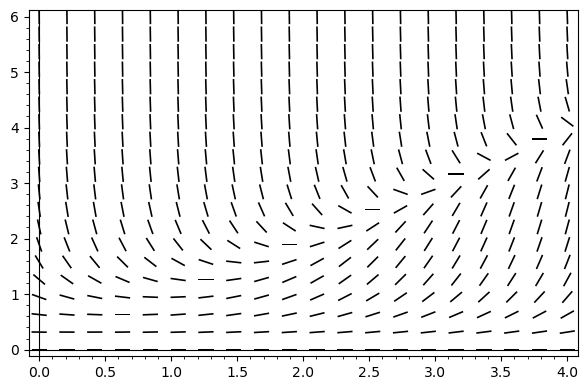

In [3]:
var('x, y')

# Die Funktion, deren Steigungsfeld Sie plotten möchten
func = (x - y) * y**2

# Erstellen des Richtungsfeldes
example = plot_slope_field(func, (x, 0, 4), (y, 0, 6))

# Anzeigen des Plots
show(example)

In [4]:
# Eingabevariablen sind rechte Seite der Differenzialgleichung (f), 
# h = Schrittlänge
# initial conditions (ics), Anzahl der Schritte (n)
# gibt eine Liste von Punkten zurück
def Euler(f, ics, h, n):
    xx = [ics[0]]
    yy = [ics[-1]]
    for k in range(n):
        # letztes Elemnt + Schritt
        xx.append(xx[-1] + h)
        # 
        yy.append(yy[-1] + h * f.subs(x = xx[-1], y = yy[-1]))
        
        points = list(zip(xx, yy))
    return (points)

In [5]:
# Liste von x und y Werten

points = Euler(func, [0,1], 0.1, 40)

# Anzeige der ersten 10 Punkte
for k in range (10):
    print(points[k])

(0, 1)
(0.100000000000000, 0.910000000000000)
(0.200000000000000, 0.851204900000000)
(0.300000000000000, 0.811267360998672)
(0.400000000000000, 0.784199605063062)
(0.500000000000000, 0.766722209785546)
(0.600000000000000, 0.756921228828417)
(0.700000000000000, 0.753660042307244)
(0.800000000000000, 0.756292167934901)
(0.900000000000000, 0.764511937519600)


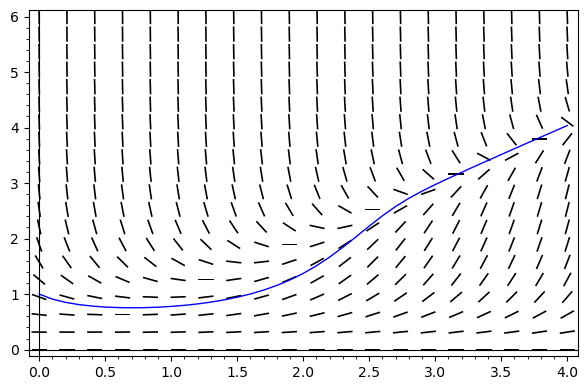

In [6]:
# Punkte plotten
g = list_plot(points, plotjoined=True)
sf = plot_slope_field(func,(x,0,4),(y, 0,6))

# gibt Richtungsfelder und den Plot nach Euler aus
g + sf

## SageMath Funktionen zum Lösen von Differenzialgleichungen

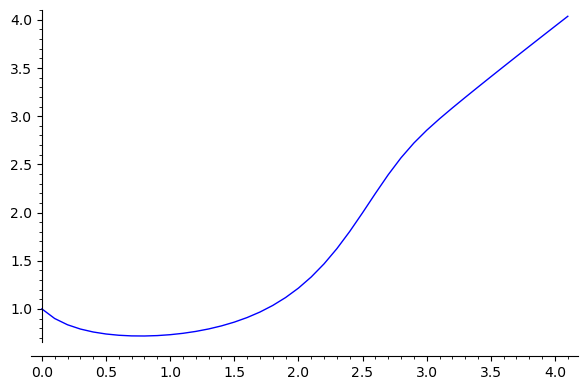

CPU times: user 5.79 ms, sys: 0 ns, total: 5.79 ms
Wall time: 5.95 ms


In [7]:
# func mit vordefinierter Euler Methode lösen
f(x, y) = (x - y) * y**2
euler = eulers_method(f, 0, 1, 0.1, 4, algorithm='none')
list_plot(euler, plotjoined=True )
%time euler = eulers_method(f, 0, 1, 0.1, 4, algorithm='none')

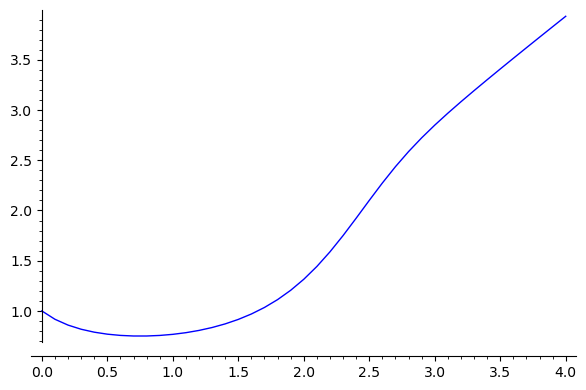

CPU times: user 12.8 ms, sys: 703 µs, total: 13.5 ms
Wall time: 148 ms


In [8]:
rk4 =desolve_rk4(func, y, [0, 1], x, 4.0, step=0.1, output='plot')
rk4
%time rk4 =desolve_rk4(func, y, [0, 1], x, 4.0, step=0.1, output='plot')

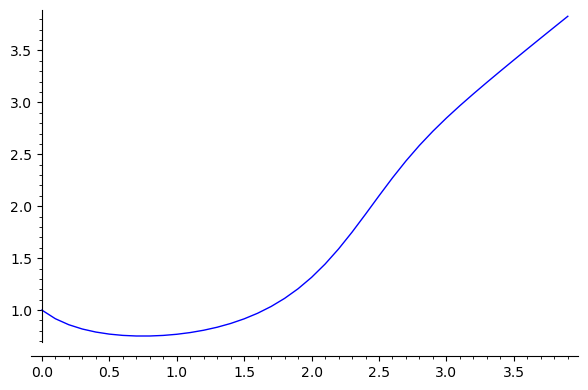

CPU times: user 2.13 ms, sys: 190 µs, total: 2.32 ms
Wall time: 2.44 ms


In [9]:
x, y = var('x, y')
x_points = srange(0, 4, 0.1)
solution_odeint = desolve_odeint(func, [1], x_points, [y])

plot_data = []

for i in range(len(x_points)):
    plot_data.append([x_points[i], solution_odeint[i][0]])
    
list_plot(plot_data, plotjoined=True)

%time solution_odeint = desolve_odeint(func, [1], x_points, [y])


## Euler vs. RK4 vs. OdeInt in SageMath: RK4 bevorzugen

Laut offizieller SageMath Doku ist desolve_rk4() schneller und genauer als eulers_method().
Wie hier jedoch zu sehen ist, ist eulers_method() sehr ähnlich was Genauigkeit betrifft und deutlich schneller als desolve_rk4().\
Noch schneller bei ähnlicher Genauigkeit ist jedoch desolve_odeint(), was uns darauf schließen lässt, dass es sich trotz anderer Angaben der Dokumentation lohnen kann, mit den verschiedenen solvern zu experimentieren, bzw. fast immer desolve_odeint() zu verwenden, da dieser in der Praxis und laut der Dokumentation am schnellsten (und genauesten) ist.

# Populations-Modelle als Differenzialgleichugnen

📈 **Populationsdynamik**: Löse und plotte die exponentielle Wachstums-DGL `dP/dt = r·P` mit Anfangsbedingung `P(0) = 50`.

In [10]:
# Exponentielles Wachstum: dP/dt = r*P
var('t r')
P = function('P')(t)  # P ist Funktion von t

# Lösen mit expliziter Angabe der unabhängigen Variable (ivar=t)
exact_solution = desolve(diff(P,t) == r*P, P, ivar=t, ics=[0, 50])
show("Exakte Lösung: ", exact_solution)

(t, r)

'Exakte Lösung: ' 50*e^(r*t)

(t, r)

'Exakte Lösung: ' 50*e^(r*t)

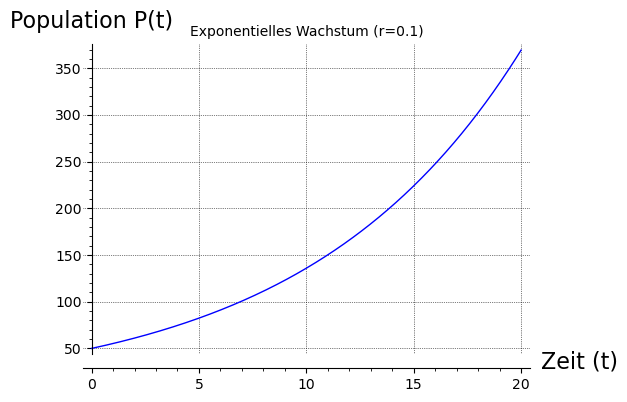

In [11]:
var('t r')
P = function('P')(t)

exact_solution = desolve(diff(P,t) == r*P, P, ivar=t, ics=[0, 50])

show("Exakte Lösung: ", exact_solution)

plot_solution = plot(exact_solution.subs(r=0.1), (t, 0, 20),
                 color='blue',
                 axes_labels=['Zeit (t)', 'Population P(t)'],
                 title='Exponentielles Wachstum (r=0.1)',
                 gridlines=True)
plot_solution.show()

🌿 **Logistisches Wachstum (mit Maximum)**  
`dP/dt = r·P(1-P/K)` mit `K=1000`  
→ S-förmige Kurve, stabil bei `P=K`

t

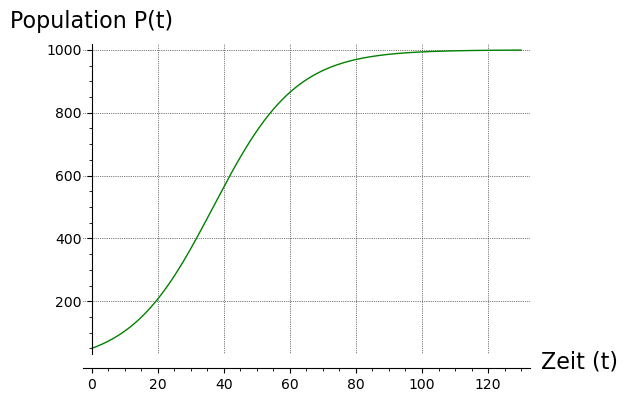

In [12]:
# SageMath-Code
var('t')
P = function('P')(t)  # P als Funktion von t definieren

r = 0.08    # Wachstumsrate
K = 1000   # Maximum
dgl = diff(P,t) == r * P * (1 - P/K)

numerical_sol = desolve_rk4(
    dgl,
    P,
    ics=[0, 50],      # Startwert P(0)=50
    ivar=t,
    end_points=130,   # Zeitbereich 0-130
    output='list'     # Als Liste für den Plot
)

# Plot
list_plot(numerical_sol, 
         plotjoined=True, 
         color='green',
         axes_labels=['Zeit (t)', 'Population P(t)'],
         gridlines=True)

## Eigene Eulermethode für Lokta Volterra

In [14]:
def EulerLV(fx, fy, ics, h, n):
    xs = [ics[0]]  # Werte von x (z.B. Population Räuber)
    ys = [ics[1]]  # Werte von y (z.B. Population Beute)
    for k in range(n):
        xk = xs[-1]
        yk = ys[-1]
        dx = fx.subs(x=xk, y=yk)
        dy = fy.subs(x=xk, y=yk)
        xs.append(xk + h * dx)
        ys.append(yk + h * dy)
    return xs, ys

In [15]:
# Parameter
alpha = 1.1
beta = 0.4
gamma = 0.4
delta = 0.1

# Variablen (symbolisch)
(x, y) = var('x y')

f_dxdt = alpha * x - beta * x * y
f_dydt = delta * x * y - gamma * y


In [16]:
x0 = 10
y0 = 5
h = 0.01
n = 2000

xs, ys = EulerLV(f_dxdt, f_dydt, [x0, y0], h, n)



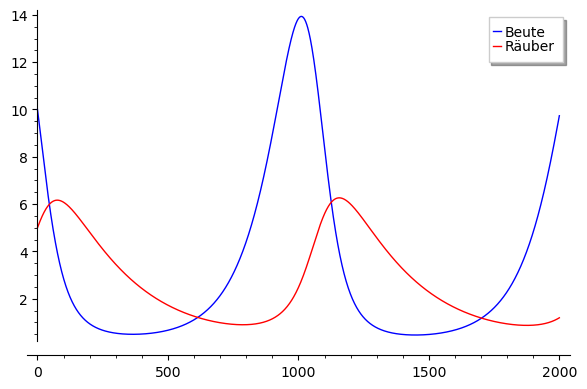

In [17]:
#Lokta Volterra Plotten

list_plot(list(zip(range(n+1), xs)), plotjoined=True, color='blue', legend_label='Beute') + \
list_plot(list(zip(range(n+1), ys)), plotjoined=True, color='red', legend_label='Räuber')

## Genrelle Darstellung von phasenzyklischen Lotka-Volterra-Modellen

In [18]:
T = ode_solver()
T.function = lambda t, y: [y[0]-y[0]*y[1], -y[1]+y[0]*y[1]] # x(t) = x−x⋅y -> Beute
                                                            # y(t) = -y+x⋅y -> Räuber

def plot_lotka_volterra(LV):
    sol_lines = Graphics()
    for i in srange(0.1,1.1,.1): # Verschiedene Anfangswerte von 0,1 bis 1,1 in 0,1er Schritten
        LV.ode_solve(y_0=[i,i],t_span=[0,10],num_points=1000)
        y = LV.solution
        sol_lines = sol_lines + line([x[1] for x in y], rgbcolor = (i,0,1-i))
    return sol_lines


@interact
def _(alpha=(1, (0, 5, 1)), beta=(1, (0, 5, 1)), gamma=(1, (0, 5, 1)), delta=(1, (0, 5, 1))):
    T = ode_solver()
    T.function = lambda t, y: [alpha*y[0] - beta*y[0]*y[1], delta*y[0]*y[1] - gamma*y[1]]
    show(plot_lotka_volterra(T) + point((gamma/delta, alpha/beta), size=30, rgbcolor=(0,0,0)), figsize=[6,6], axes_labels=['Räuber', 'Beute'])

# alpha -> Wachstum Beute
# beta -> Fangrate
# gamma -> Sterberate Räuber
# delta -> Wachstum Räuber durch Fang von Beute

Widget Javascript not detected.  It may not be installed or enabled properly. Reconnecting the current kernel may help.


## Generelle Darstellung von Lotka-Volterra-Modellen nach Zeit

In [19]:
def plot_lotka_volterra_t(LV, startwert):
    LV.ode_solve(y_0=[startwert,startwert],t_span=[0,10],num_points=1000)
    data = LV.solution
    t_values  = [t for (t, y) in data]
    y1_values = [y[0] for (t, y) in data]
    y2_values = [y[1] for (t, y) in data]
    plot1 = line(zip(t_values, y1_values), color='blue', legend_label='Beute')
    plot2 = line(zip(t_values, y2_values), color='red', legend_label='Räuber')
    plot = plot1 + plot2
    return plot

@interact
def _(alpha=(1, (0, 5, 1)), beta=(1, (0, 5, 1)), gamma=(1, (0, 5, 1)), delta=(1, (0, 5, 1)), startwert=(1, (1, 10, 1))):
    T = ode_solver()
    T.function = lambda t, y: [alpha*y[0] - beta*y[0]*y[1], delta*y[0]*y[1] - gamma*y[1]]
    show(plot_lotka_volterra_t(T, startwert), figsize=[6,6], axes_labels=['Zeit (s)', 'Populationsgröße'])

# alpha -> Wachstum Beute
# beta -> Fangrate
# gamma -> Sterberate Räuber
# delta -> Wachstum Räuber durch Fang von Beute

Widget Javascript not detected.  It may not be installed or enabled properly. Reconnecting the current kernel may help.


### Stewart Buch Aufgabe 10

In [20]:
A, L, t = var('A, L, t')

#Differentialgleichungen
dA_dt = 2*A - 0.01*A*L
dL_dt = -0.5*L + 0.0001*A*L

# (a) Gleichgewichtslösungen finden

# Setze dA/dt = 0 und dL/dt = 0
# Die Funktion solve() kann dies für uns tun
equilibrium_solutions = solve([dA_dt == 0, dL_dt == 0], A, L)

print("\n(a) Gleichgewichtslösungen:")
for sol in equilibrium_solutions:
    print(sol)


# dL/dA = (dL/dt) / (dA/dt)
dL_dA = dL_dt / dA_dt

print("\n(b) Ausdruck für dL/dA:")
print("dL/dA =", dL_dA)


(a) Gleichgewichtslösungen:
[A == 0, L == 0]
[A == 5000, L == 200]

(b) Ausdruck für dL/dA:
dL/dA = (0.000100000000000000*A*L - 0.500000000000000*L)/(-0.0100000000000000*A*L + 2*A)


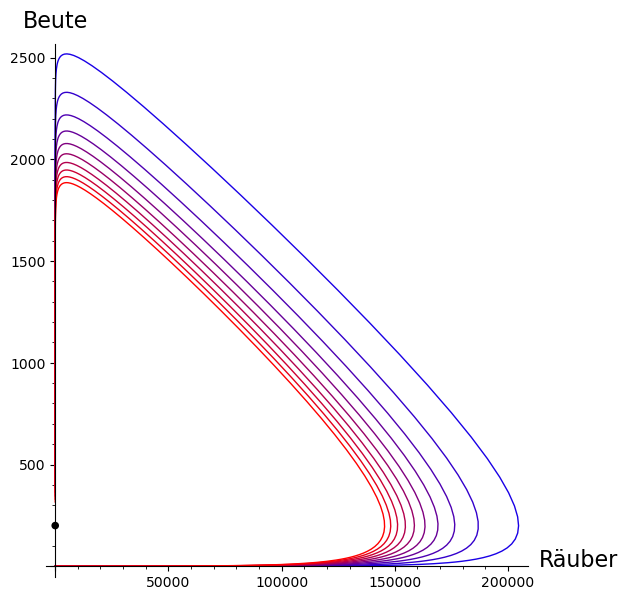

In [21]:
#Steward 9.6 10d
F = ode_solver()
F.function = lambda t, y: [2*y[0]-0.01*y[0]*y[1], 0.5*-y[1]+0.0001*y[0]*y[1]]

show(plot_lotka_volterra(F) + point((0.0001/0.5, 2/0.01), size=30, rgbcolor=(0,0,0)), figsize=[6,6], axes_labels=['Räuber', 'Beute'])
    

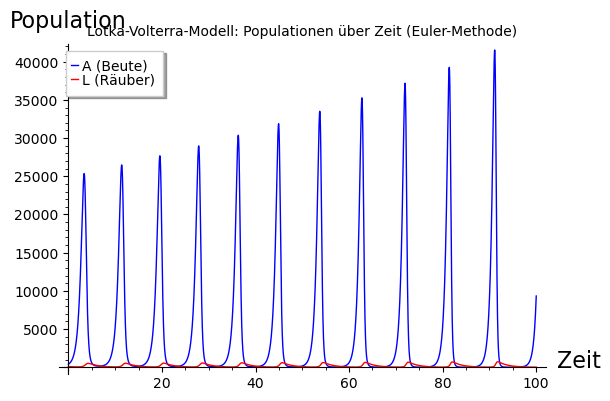

In [22]:
x, y = var('x y')

fx_lotka_volterra = 2*x - 0.01*x*y
fy_lotka_volterra = -0.5*y + 0.0001*x*y

# Anfangsbedingungen [Anfangspopulation A, Anfangspopulation L]
initial_conditions = [400, 100] # Beispielwerte: 400 für A (Beute), 100 für L (Räuber)

# Simulationsparameter
h_step = 0.01
n_steps = 10000

# Numerische Lösung mit EulerLV
results_x, results_y = EulerLV(fx_lotka_volterra, fy_lotka_volterra, initial_conditions, h_step, n_steps)

# Zeitpunkte für den Plot
time_points = [k * h_step for k in range(n_steps + 1)]

# Plotten der Ergebnisse
# 1. Zeitreihenplot (Population vs. Zeit)
plot_A = line(zip(time_points, results_x), color='blue', legend_label='A (Beute)')
plot_L = line(zip(time_points, results_y), color='red', legend_label='L (Räuber)')

show(plot_A + plot_L,
     title='Lotka-Volterra-Modell: Populationen über Zeit (Euler-Methode)',
     axes_labels=['Zeit', 'Population'],
     ymin=0) # Sicherstellen, dass die Populationen nicht unter 0 fallen
